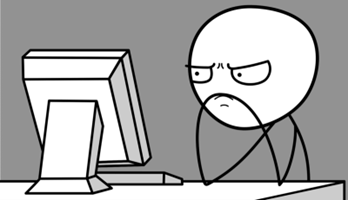

Para ejercitarte y afianzar lo aprendido sobre tendencias centrales, frecuencias, medidas de posición y rangos, completa los siguientes ejercicios. Recuerda que necesitarás datos que están en el directorio data que acompaña al notebook (búscalo en el repositorio de ejercicios)
  
La solución a los mismos se subirá a lo largo del sprint.

### Ejercicio 0


Importa los paquetes y módulos que necesites a lo largo del notebook

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [10]:
def pinta_distribucion_categoricas(df, columnas_categoricas, relativa=False, mostrar_valores=False):
    num_columnas = len(columnas_categoricas)
    num_filas = (num_columnas // 2) + (num_columnas % 2)

    fig, axes = plt.subplots(num_filas, 2, figsize=(15, 5 * num_filas))
    axes = axes.flatten() 

    for i, col in enumerate(columnas_categoricas):
        ax = axes[i]
        if relativa:
            total = df[col].value_counts().sum()
            serie = df[col].value_counts().apply(lambda x: x / total)
            sns.barplot(x=serie.index, y=serie, ax=ax, palette='viridis', hue = serie.index, legend = False)
            ax.set_ylabel('Frecuencia Relativa')
        else:
            serie = df[col].value_counts()
            sns.barplot(x=serie.index, y=serie, ax=ax, palette='viridis', hue = serie.index, legend = False)
            ax.set_ylabel('Frecuencia')

        ax.set_title(f'Distribución de {col}')
        ax.set_xlabel('')
        ax.tick_params(axis='x', rotation=45)

        if mostrar_valores:
            for p in ax.patches:
                height = p.get_height()
                ax.annotate(f'{height:.2f}', (p.get_x() + p.get_width() / 2., height), 
                            ha='center', va='center', xytext=(0, 9), textcoords='offset points')

    for j in range(i + 1, num_filas * 2):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()


In [43]:
def plot_multiple_boxplots(df, columns, dim_matriz_visual = 2):
    num_cols = len(columns)
    num_rows = num_cols // dim_matriz_visual + num_cols % dim_matriz_visual
    fig, axes = plt.subplots(num_rows, dim_matriz_visual, figsize=(12, 6 * num_rows))
    axes = axes.flatten()

    for i, column in enumerate(columns):
        if df[column].dtype in ['int64', 'float64']:
            sns.boxplot(data=df, x=column, ax=axes[i])
            axes[i].set_title(column)

    # Ocultar ejes vacíos
    for j in range(i+1, num_rows * 2):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

### Ejercicio 1

Carga en un dataframe los datos contenidos en la ruta "./data/admission_data.csv", muestra un parte de su contenido y la info general del mismo

In [5]:
df = pd.read_csv("./data/admission_data.csv", index_col = 0)
df.head()

,Year,Major,Gender,Admission
0,1973,School of Medicine,F,Rejected
1,1973,Department of Economics,M,Accepted
2,1973,Other,F,Accepted
3,1973,Other,M,Accepted
4,1973,Other,M,Rejected


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12763 entries, 0 to 12762
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  12763 non-null  int64 
 1   Year        12763 non-null  int64 
 2   Major       12763 non-null  object
 3   Gender      12763 non-null  object
 4   Admission   12763 non-null  object
dtypes: int64(2), object(3)
memory usage: 498.7+ KB


### Ejercicio 2

Como ya sabes este dataset queremos analizarlo para poder estudiar la posible discriminación en las admisiones de los departamentos universitarios. Analiza la variable `Year`, ¿qué crees que deberíamos hacer con esta variable?

La variable Year muestra el año de solicitud del estudiante, nos muentran todas las solicitudes de un solo año por lo que la variable no aporta variabilidad ni información útil para analizar patrones de discriminación o diferencias entre grupos. Lo que haria con la variable year es eliminarla 

In [7]:
df_copy = df.drop(columns= "Year").copy()

### Ejercicio 3

Analiza ahora la columna `Major`, obtén las frecuencias absolutas y relativas de forma numérica y de forma gráfica. Puedes emplear las funciones del notebook de visualizaciones del repo o bien la función `pinta_distribucion_categoricas` del módulo `bootcampviztools` y que hemos usado en el workout. (Tiene un argumento `relativa` para mostrar las frecuencias relativas y otro `mostrar_valores` para enseñar las etiquetas de los valores).

In [17]:
#Frecuencia absoluta
print("Frecuencia absoluta:\n",df["Major"].value_counts())
print("\n")
#Frecuencia relativa
print("Frecuencia relativa:\n",df["Major"].value_counts()/len(df) *100)


Frecuencia absoluta:
 Major
Other                                                      7924
Department of Physics and Astronomy                        1246
School of Medicine                                          918
Department of Mechanical Engineering                        792
Department of Psychology                                    714
Department of Economics                                     585
School of Political Science and International Relations     584
Name: count, dtype: int64


Frecuencia relativa:
 Major
Other                                                      62.085717
Department of Physics and Astronomy                         9.762595
School of Medicine                                          7.192666
Department of Mechanical Engineering                        6.205438
Department of Psychology                                    5.594296
Department of Economics                                     4.583562
School of Political Science and International Relation

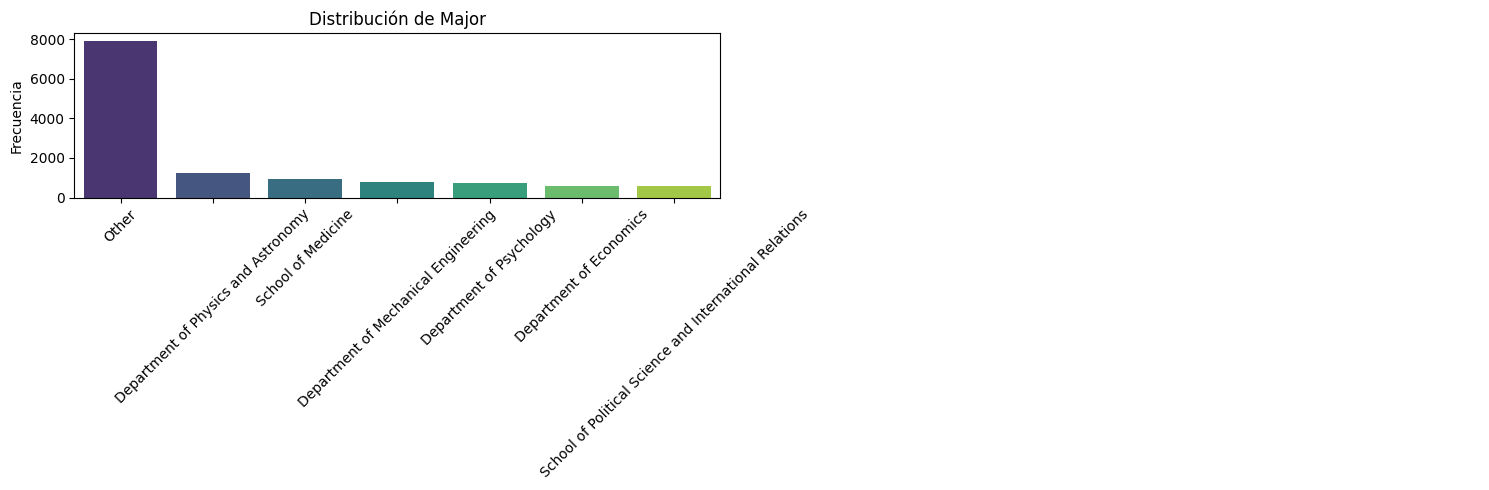

In [19]:
pinta_distribucion_categoricas(df,["Major"])

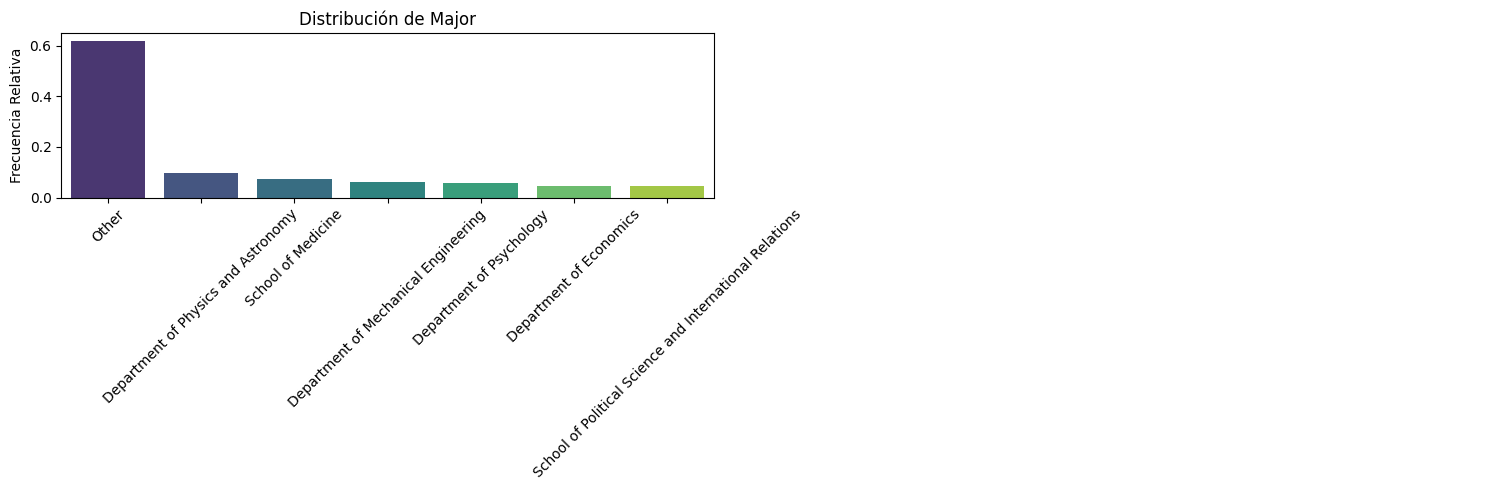

In [22]:
pinta_distribucion_categoricas(df,["Major"],relativa = True)

### Ejercicio 4

¿Qué puedes comentar de los datos anteriores?

La distribución está muy desequilibrada: más del 60% de los estudiantes aparecen en la categoría ‘Other’. Esto hace difícil comparar departamentos y limita lo que podemos analizar con esta variable.

### Ejercicio 5

Analiza ahora la columna `Gender`, obtén las frecuencias absolutas y relativas de forma numérica y de forma gráfica. 

In [23]:
#Frecuencia absoluta
print("Frecuencia absoluta:\n",df["Gender"].value_counts())
print("\n")
#Frecuencia relativa
print("Frecuencia relativa:\n",df["Gender"].value_counts()/len(df) *100)

Frecuencia absoluta:
 Gender
M    8442
F    4321
Name: count, dtype: int64


Frecuencia relativa:
 Gender
M    66.144323
F    33.855677
Name: count, dtype: float64


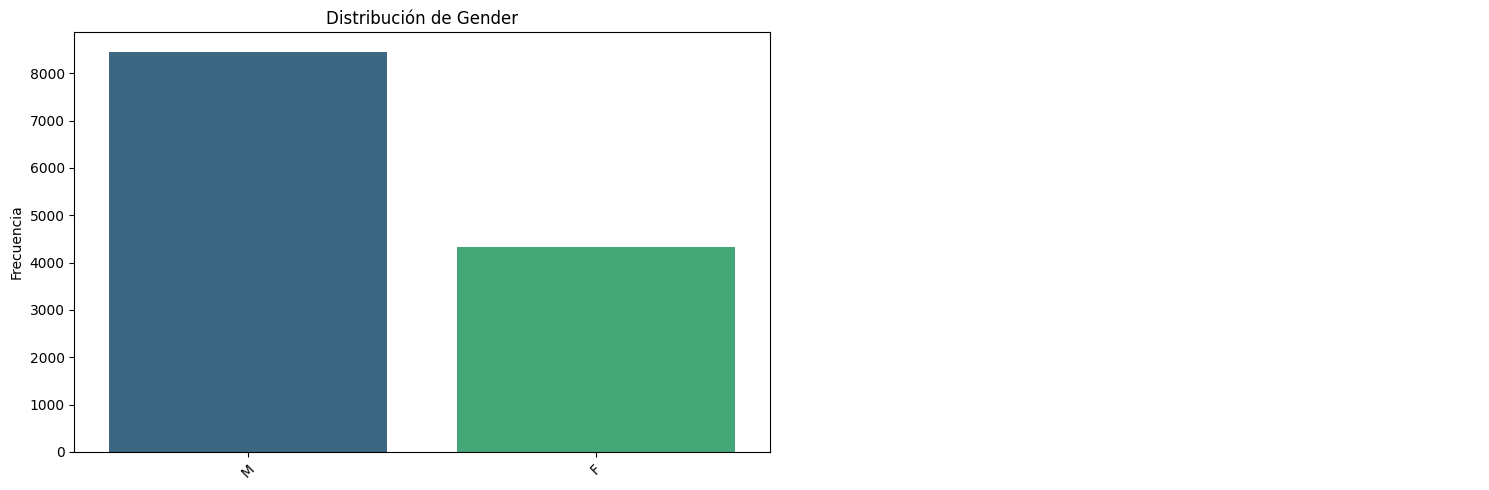

In [24]:
pinta_distribucion_categoricas(df,["Gender"])

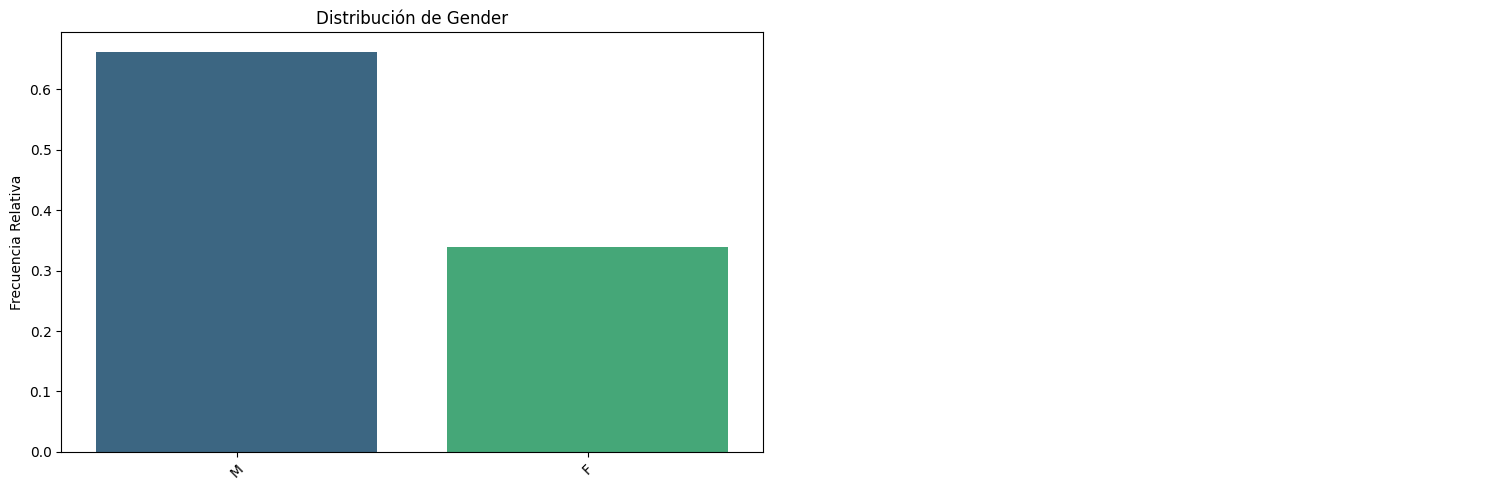

In [25]:
pinta_distribucion_categoricas(df,["Gender"], relativa = True)

### Ejercicio 6

¿Qué puedes comentar de los datos anteriores?

Se observa que hay más solicitudes de estudiantes varones que de mujeres. Sin embargo, con esta información sola no podemos concluir si existe discriminación en la admisión, ya que aún no comparamos estos datos con quiénes fueron finalmente admitidos.

### Ejercicio 7

Finalmente analiza, la columna `Admission`, obtén las frecuencias absolutas y relativas de forma numérica y de forma gráfica. 

In [26]:
#Frecuencia absoluta
print("Frecuencia absoluta:\n",df["Admission"].value_counts())
print("\n")
#Frecuencia relativa
print("Frecuencia relativa:\n",df["Admission"].value_counts()/len(df) *100)

Frecuencia absoluta:
 Admission
Rejected    7531
Accepted    5232
Name: count, dtype: int64


Frecuencia relativa:
 Admission
Rejected    59.006503
Accepted    40.993497
Name: count, dtype: float64


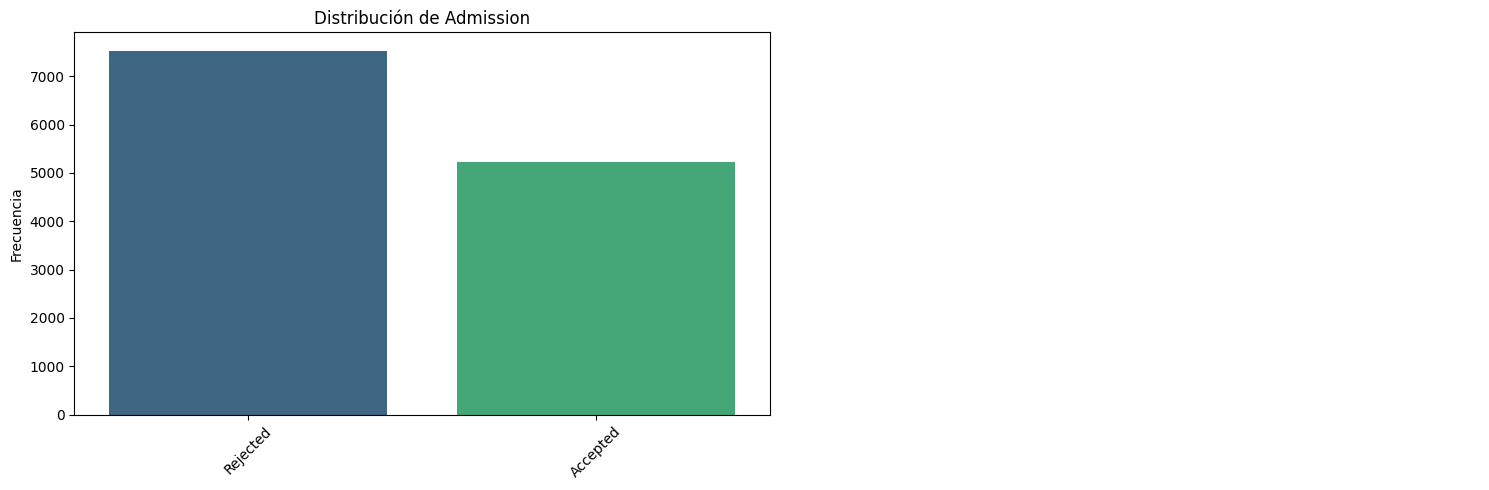

In [31]:
pinta_distribucion_categoricas(df,["Admission"])

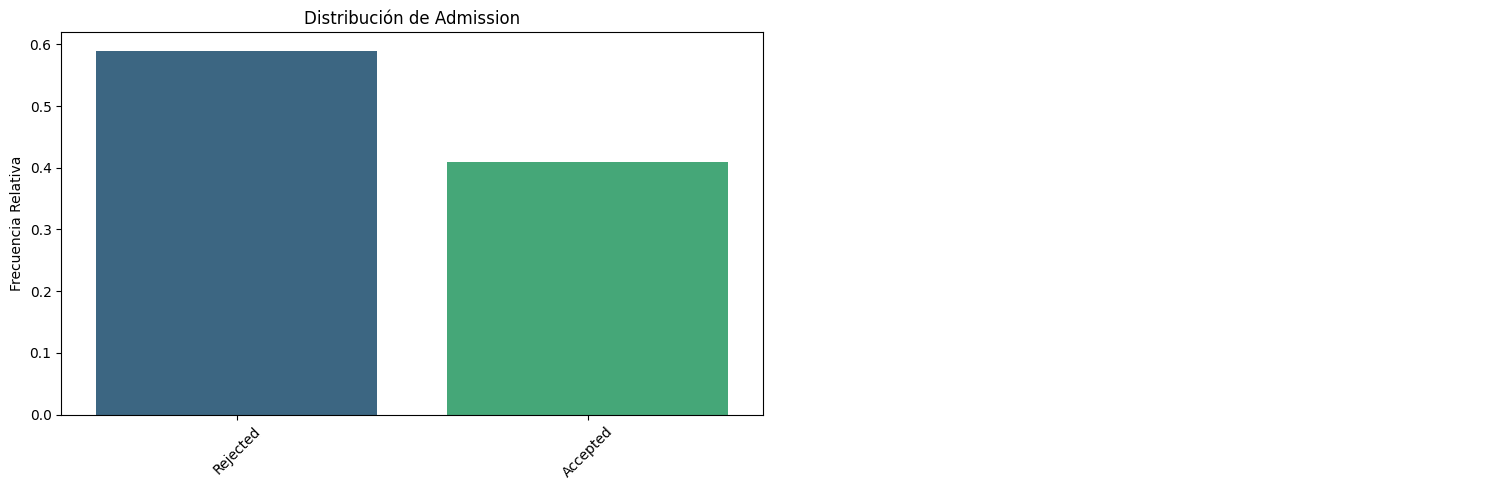

In [30]:
pinta_distribucion_categoricas(df,["Admission"], relativa = True)

### Ejercicio 8

¿Qué puedes comentar de los datos anteriores?

Se observa que hay más solicitudes rechazadas que aceptadas. Sin embargo, con esta variable sola no podemos decir si existe algún sesgo; necesitamos analizarla junto con género y departamento.

### Ejercicio 9

Carga en un dataframe los datos contenidos en la ruta "./data/tips.csv", muestra un parte de su contenido y la info general del mismo

In [36]:
df2 = pd.read_csv("./data/tips.csv", index_col = 0)
df2

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


### Ejercicio 10

Vamos a analizar las medidas de tendencia central (media, mediana), las de posición (los cuartiles) y los rangos de las variables numéricas del dataset. Muestra esos valores para todas las variables numéricas del dataset.

In [41]:
df2.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [42]:
df2.describe().loc["max"] - df2.describe().loc["min"]

total_bill    47.74
tip            9.00
size           5.00
dtype: float64

### Ejercicio 11

Para completar el análisis incial de las variables numéricas, muestra el diagrama de caja (*boxplot*) para cada una de las variables numéricas del dataset. ¿Qué puedes decir de ellas? (Puedes emplear las funciones incluidas en el notebook de visualizaciones sencillas o la función `plot_multiple_boxplots` de `bootcampviztools`, y que hemos empleado en el workout)

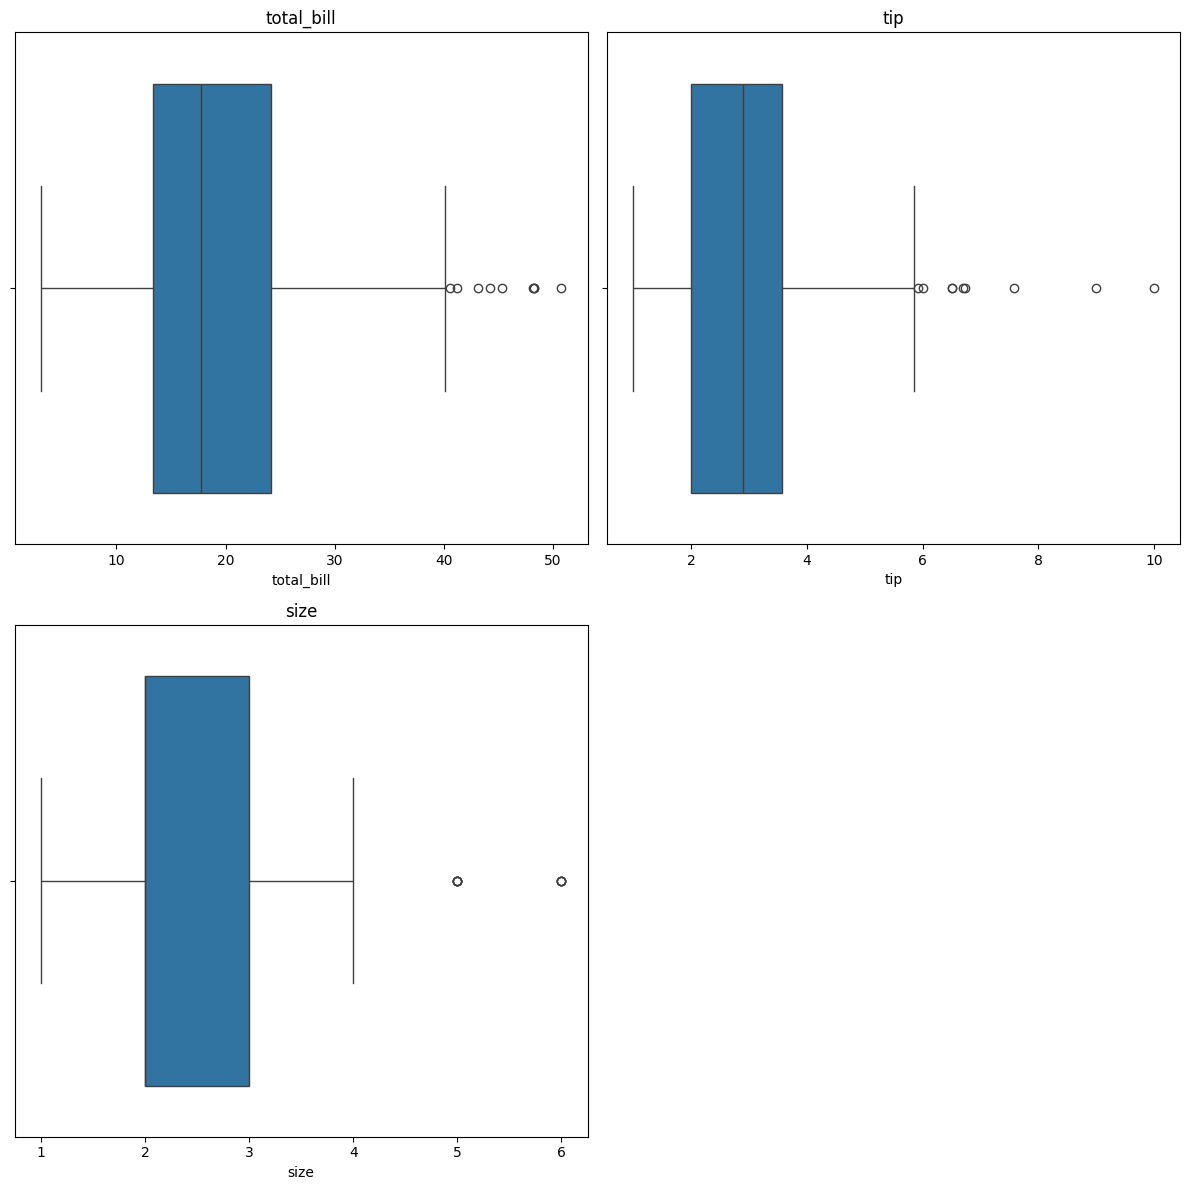

In [44]:
columnas_numericas = df2.describe().T.index.to_list()
plot_multiple_boxplots (df2,columnas_numericas)

### Ejercicio Extra #1:

Muestra las frecuencias absolutas y relativas de las variables categóricas del dataset. ¿Qué podrías destacar?

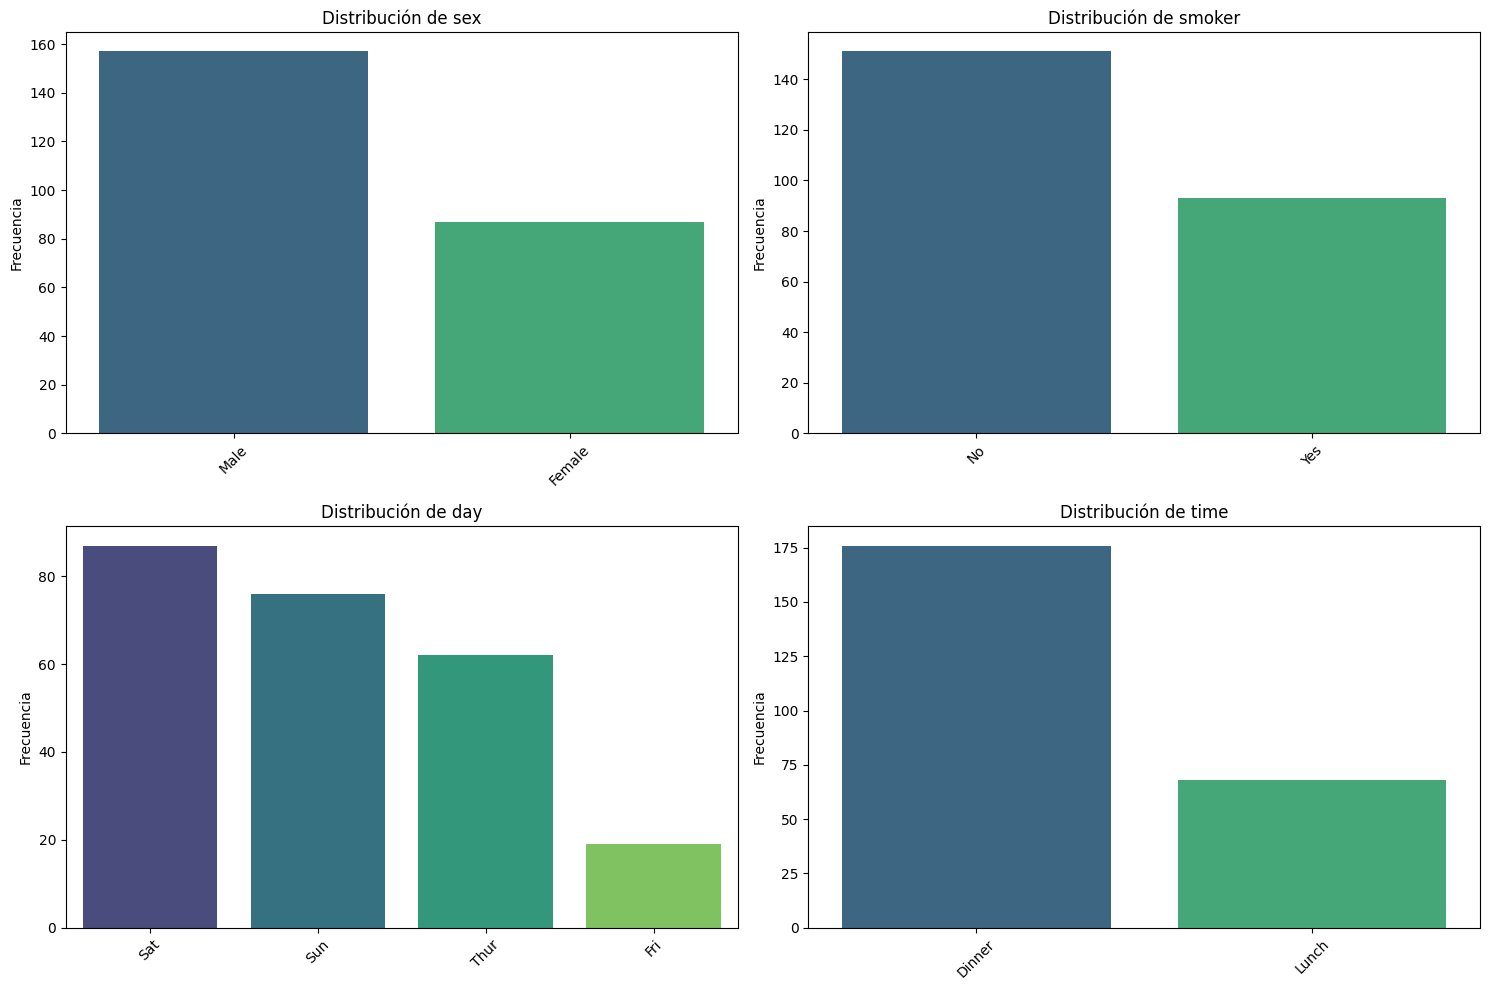

In [50]:
columnas_categoricas = ['sex', 'smoker', 'day', 'time']
pinta_distribucion_categoricas(df2,columnas_categoricas )

### Ejercicio Extra #2:

Carga en un dataframe el dataset de los seguros que tanto conoces ya ("./data/Marketing-Customer-Analysis.csv") y analiza cual es el perfil típico del cliente de la compañía a partir de las variables categóricas siguientes: `education, state, employmentstatus, gender, marital_status, vehicle_class, vehicle_size`. (Nota: en el workout lo hicimos a partir de las modas de dichos valores, pero no es la forma "precisa" de hacerlo, piensa en la "moda" sí pero de la combinación de valores)


In [51]:
df = pd.read_csv("./data/Marketing-Customer-Analysis.csv")
categorias = ["education","state","employmentstatus","gender",
              "marital_status","vehicle_class","vehicle_size"]

df[categorias].mode().T

,0
education,Bachelor
state,California
employmentstatus,Employed
gender,F
marital_status,Married
vehicle_class,Four-Door Car
vehicle_size,Medsize


“El cliente típico de la compañía, según las variables categóricas analizadas, presenta el siguiente perfil:
Nivel educativo: Bachelor (la categoría más frecuente).  
Estado de residencia: California (es el estado predominante).  
Situación laboral: Employed (la mayoría de los clientes están empleados).  
Género: Female (ligero predominio femenino).  
Estado civil: Married (la mayoría están casados).  
Clase de vehículo: Four-Door Car (el tipo de vehículo más común).  
Tamaño del vehículo: Medsize (predomina el vehículo de tamaño mediano).  
En conjunto, estos valores representan la combinación más habitual dentro del dataset y permiten definir un perfil general del cliente de la aseguradora.”  